In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 처음 실행하는 경우 아래 두 줄의 주석을 풀어 설치하세요.
# !pip install missingno plotly -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import plotly.express as px
import plotly.io as pio

warnings.filterwarnings("ignore")
np.random.seed(42)

# 한글 폰트 (운영체제별 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# Plotly는 환경에 따라 기본 렌더러가 다릅니다.
# 노트북에서 인터랙티브로 보이도록 명시적으로 지정합니다.
try:
    pio.renderers.default = "notebook"
except Exception:
    pass

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("pandas    :", pd.__version__)
print("seaborn   :", sns.__version__)
print("missingno :", msno.__version__ if hasattr(msno, "__version__") else "(installed)")

준비 완료! 라이브러리 버전을 확인합니다.
pandas    : 3.0.3
seaborn   : 0.13.2
missingno : 0.5.2


In [2]:
# ─────────────────────────────────────────────
# 모두마켓 웹 접속 로그(가상) — 일부러 오염을 심어 둡니다.
# ─────────────────────────────────────────────
np.random.seed(7)
n_log = 2500
logs_raw = pd.DataFrame({
    "log_id":           [f"L{str(i).zfill(6)}" for i in range(1, n_log + 1)],
    "session_id":       np.random.choice([f"S{str(i).zfill(4)}" for i in range(1, 401)], n_log),
    "response_time_ms": np.abs(np.random.normal(180, 80, n_log)).round(0),
    "request_path":     np.random.choice(["/home", "/category", "/product", "/cart", "/checkout"], n_log,
                                         p=[0.35, 0.2, 0.25, 0.1, 0.1]),
    "device":           np.random.choice(["mobile", "Mobile", "MOBILE", "desktop", "DESKTOP"], n_log,
                                         p=[0.35, 0.15, 0.2, 0.2, 0.1]),
    "hour":             np.random.randint(0, 24, n_log),
    "is_error":         np.random.choice([0, 1], n_log, p=[0.97, 0.03]),
})
# 의도적 오염
# (a) response_time_ms 결측 (심야 시간대에 많이 — 측정 모듈 점검 시간) — MAR 패턴
night = logs_raw["hour"].isin([2, 3, 4])
night_idx = logs_raw[night].sample(min(80, night.sum()), random_state=1).index
day_idx = logs_raw[~night].sample(40, random_state=1).index
logs_raw.loc[night_idx, "response_time_ms"] = np.nan
logs_raw.loc[day_idx, "response_time_ms"] = np.nan
# (b) response_time_ms 이상치 (네트워크 정체로 60초·45초 지연된 응답)
logs_raw.loc[5, "response_time_ms"] = 60_000
logs_raw.loc[6, "response_time_ms"] = 45_000
# (c) hour 이상치 (잘못된 값)
logs_raw.loc[100, "hour"] = 99
# (d) 중복
logs_raw = pd.concat([logs_raw, logs_raw.iloc[[0, 1]]], ignore_index=True)

print("웹 로그 준비:", logs_raw.shape, "| 결측 response_time_ms:", logs_raw["response_time_ms"].isna().sum())
logs_raw.head(3)

웹 로그 준비: (2502, 7) | 결측 response_time_ms: 120


,log_id,session_id,response_time_ms,request_path,device,hour,is_error
0,L000001,S0176,275.0,/home,Mobile,23,0
1,L000002,S0197,217.0,/category,mobile,8,0
2,L000003,S0026,85.0,/home,desktop,6,0


log_id                0
session_id            0
response_time_ms    120
request_path          0
device                0
hour                  0
is_error              0
dtype: int64
log_id              0.0
session_id          0.0
response_time_ms    4.8
request_path        0.0
device              0.0
hour                0.0
is_error            0.0
dtype: float64


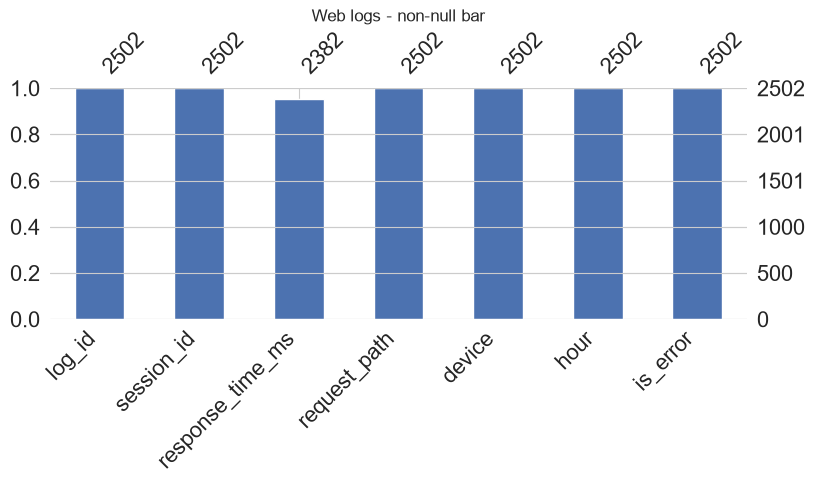

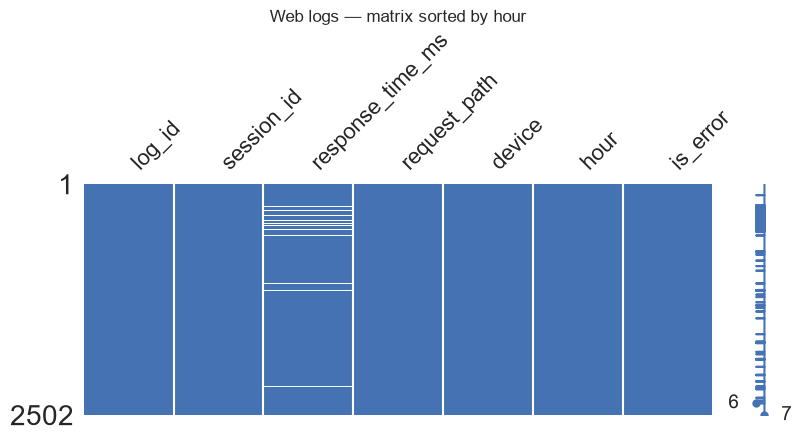

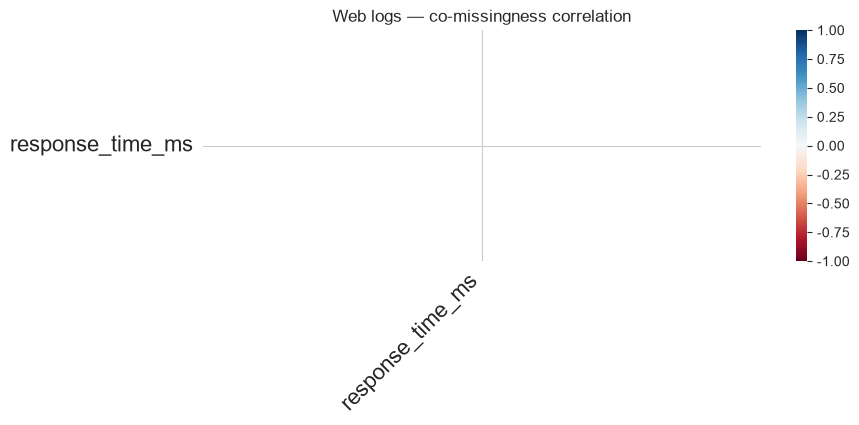

In [3]:
# 시나리오 1 — 결측 진단
print(logs_raw.isnull().sum())
print((logs_raw.isnull().mean() * 100).round(1))

msno.bar(logs_raw,color="#4C72B0", figsize=(9, 3))
plt.title("Web logs - non-null bar"); plt.show()

msno.matrix(logs_raw.sort_values("hour"), color=(0.27, 0.45, 0.70), figsize=(9, 3))
plt.title("Web logs — matrix sorted by hour"); plt.show()

msno.heatmap(logs_raw, figsize=(9, 3))
plt.title("Web logs — co-missingness correlation"); plt.show()

In [4]:
# 시나리오 2 — 정제
logs_clean = logs_raw.drop_duplicates(subset="log_id").reset_index(drop=True)

# device 표기 통일 (대소문자 혼재)
device_map = {"mobile": "mobile", "Mobile": "mobile", "MOBILE": "mobile",
              "desktop": "desktop", "DESKTOP": "desktop"}
logs_clean["device"] = logs_clean["device"].map(device_map)

# hour 이상치 제거 (사실 0~23 외는 모두 이상)
logs_clean = logs_clean[logs_clean["hour"].between(0, 23)].copy()

# response_time_ms 결측 — 요청 경로별 중앙값으로 대체
medians = logs_clean.groupby("request_path")["response_time_ms"].median()
need = logs_clean["response_time_ms"].isna()
logs_clean.loc[need, "response_time_ms"] = logs_clean.loc[need, "request_path"].map(medians)

# response_time_ms 클리핑 (p99)
cap = logs_clean["response_time_ms"].quantile(0.99)
logs_clean.loc[logs_clean["response_time_ms"] > cap, "response_time_ms"] = cap

print("clean 모양:", logs_clean.shape, "| 결측 response_time_ms:", logs_clean["response_time_ms"].isna().sum())

clean 모양: (2499, 7) | 결측 response_time_ms: 0


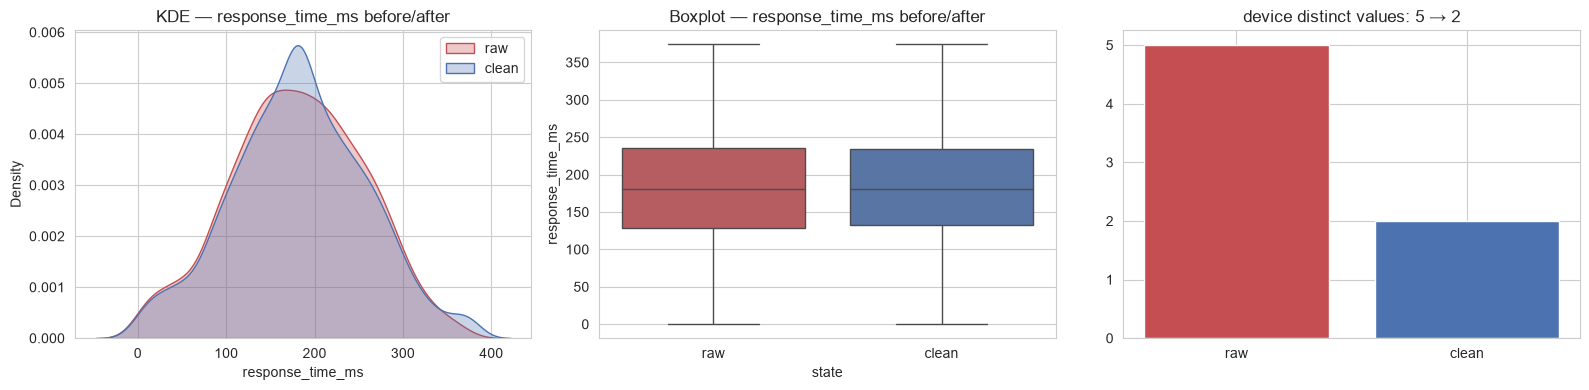

In [5]:
# 검증 — 전후 분포 비교 (3종 세트)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) KDE 겹쳐
raw_rt = logs_raw["response_time_ms"].dropna()
raw_rt = raw_rt[raw_rt <= cap]
sns.kdeplot(raw_rt, label="raw", color="#C44E52", fill=True, alpha=0.3, ax=axes[0])
sns.kdeplot(logs_clean["response_time_ms"], label="clean", color="#4C72B0", fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("KDE — response_time_ms before/after"); axes[0].legend()

# (b) 박스 side-by-side
long_rt = pd.concat([
    pd.DataFrame({"response_time_ms": raw_rt.values, "state": "raw"}),
    pd.DataFrame({"response_time_ms": logs_clean["response_time_ms"].values, "state": "clean"})
])
sns.boxplot(data=long_rt, x="state", y="response_time_ms",
            order=["raw", "clean"], ax=axes[1], palette=["#C44E52", "#4C72B0"])
axes[1].set_title("Boxplot — response_time_ms before/after")


# (c) device 정제 검증
raw_dev_n = logs_raw["device"].nunique()
clean_dev_n = logs_clean["device"].nunique()
axes[2].bar(["raw", "clean"], [raw_dev_n, clean_dev_n], color=["#C44E52", "#4C72B0"])
axes[2].set_title(f"device distinct values: {raw_dev_n} → {clean_dev_n}")

plt.tight_layout(); plt.show()

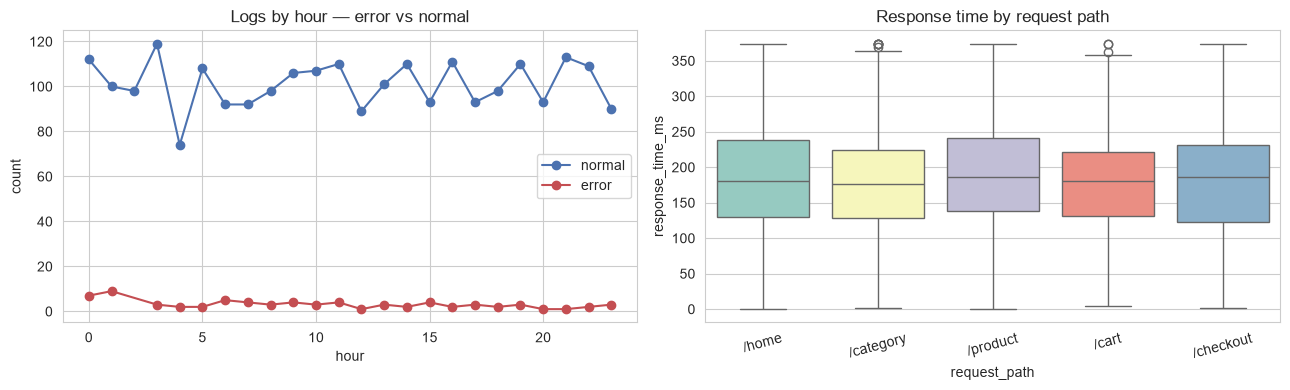

In [6]:
# 시나리오 3 — 탐색# 시나리오 3 — 탐색
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) 시간대별 로그 수 — 에러 vs 정상 비교
hour_err = logs_clean.groupby(["hour", "is_error"]).size().reset_index(name="n")
for label, color in [(0, "#4C72B0"), (1,"#C44E52")]:
    part = hour_err[hour_err["is_error"] == label]
    axes[0].plot(part["hour"], part["n"], marker="o",
                 label="normal" if label == 0 else "error", color=color)
axes[0].set_title("Logs by hour — error vs normal")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("count"); axes[0].legend()

# (b) 요청 경로별 응답 시간 분포
sns.boxplot(data=logs_clean, x="request_path", y="response_time_ms",
            order=["/home", "/category", "/product", "/cart", "/checkout"],
            ax=axes[1], palette="Set3")
axes[1].set_title("Response time by request path")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

In [9]:
# 시나리오 4 — 전달용 인터랙티브 차트
err_hour = (logs_clean.groupby(["hour", "is_error"]).size()
            .reset_index(name="count"))
err_hour["is_error"] = err_hour["is_error"].map({0: "normal", 1: "error"})

fig = px.bar(err_hour, x="hour", y="count", color="is_error",
             barmode="group", title="Hourly logs — error vs normal",
             color_discrete_map={"normal": "#4C72B0", "error": "#C44E52"})
fig.update_layout(width=900, height=420)
fig.show()

fig.write_image("Hourly_error_normal.png")

# 모두마켓 웹 접속 로그 — EDA & 시각화 보고서

## 1. 데이터 개요
- 행/열: (2502행, 7열)
- 주요 컬럼: log_id, session_id, response_time_ms, request_path, device, hour, is_error

## 2. 결측 진단 (missingno)
- `response_time_ms` 결측 비율: 4.8%
- 결측 패턴: 시간 정렬 후 관찰한 결과, 결측이 심야 시간대에 집중되어 있는 경향이 관찰됨.
- 의심 가설: 심야 시간대 측정 모듈 점검으로 측정값 누락, 특정 시간대 서버 장애 발생으로 측정값 누락

## 3. 정제와 검증 (전·후 분포 비교)
- 적용한 정제: 중복 제거 / device 표기 통일 / hour 이상치 / response_time_ms 결측 대체 / 극단치 클리핑
- KDE 비교 결과: 전체적인 분포 유사하여 분포 본질 유지됨. 그러나 정제 후 중앙 피크가 더 높고 뾰족해졌으며, 이는 response_time_ms 결측을 요청 경로별 중앙값으로 대체한 결과로 추정. 또한, p99 클리핑으로 인해 정제 후 350~400 부근에서 작은 봉우리 생김.
- device distinct: 5 → 2 (정상)

## 4. 탐색에서 도출한 새 질문
- (예) "새벽 시간대 에러 응답 비중이 낮보다 높은가? 
- (예) `/checkout` 응답 시간이 다른 경로보다 길다 — 결제 단계 최적화 후보인가?
- 요청량 증가와 에러 응답 비중이 관계가 있는가?
- 응답 시간이 긴 요청은 에러 발생 가능성도 높은가?

## 5. 전달용 차트 1개 (이미지 또는 코드 인용)
![시간대별 에러](Hourly_error_normal.png)
- 심야(0~1시) 시간대에 에러 건수가 높게 나타나며, 요청량을 고려한 시간대별 에러율까지 확인해봐야 실제로 문제가 있는 구간인지 판단할 수 있음.

## 6. 다음 분석 제안
- 에러 응답 원인 추적 
- 시간대별 에러율 비교
- 디바이스별 에러 비교

In [13]:
# 시간대별 에러율
err_rate = (logs_clean.groupby("hour")["is_error"].mean() * 100).round(2).reset_index(name="error_rate_pct")

fig = px.bar(err_rate, x="hour", y="error_rate_pct",
             title="Hourly error rate (%)",
             color_discrete_sequence=["#C44E52"])
fig.update_layout(width=900, height=420)
fig.show()

avg_rate = err_rate["error_rate_pct"].mean().round(2)
print(f"평균 에러율: {avg_rate}%")

평균 에러율: 2.9%


- 새벽 1시 에러율이 8.26%로 전체 평균인 2.9%보다 높게 나타나 점검이 필요함.

In [14]:
fig.write_html("report_chart.html")